<a href="https://colab.research.google.com/github/christinearroyo/csst101-arroyo/blob/main/Arroyo_AIDebateAdviser_CSST101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Table 1. Debate Arguments

In [19]:
library(tibble)

df_arguments <- tibble(
  `Argument ID` = c("A001", "A002", "A003", "A004", "A005", "A006", "A007", "A008", "A009", "A010"),
  Position = c("For", "For", "For", "Against", "Against", "Against", "For", "Against", "For", "Against"),
  Topic = c("Learning", "Productivity", "AI Literacy", "Academic Integrity", "Dependency", "Assessment", "Creativity", "Bias", "Personalization", "Cost"),
  Claim = c(
    "AI can provide students with immediate learning support.",
    "AI can help students complete routine academic tasks more efficiently.",
    "Allowing AI use can help students develop AI literacy.",
    "Undisclosed AI-generated work may create academic integrity concerns.",
    "Excessive AI use may reduce students' independent problem-solving practice.",
    "AI use may make it more difficult to determine whether submitted work reflects student learning.",
    "AI tools can stimulate new ideas and creative thinking.",
    "AI algorithms may perpetuate and amplify existing societal biases.",
    "AI can tailor learning experiences to individual student needs.",
    "The implementation and maintenance of AI tools can be costly for institutions."
  )
)

df_arguments

Argument ID,Position,Topic,Claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.
A003,For,AI Literacy,Allowing AI use can help students develop AI literacy.
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.
A007,For,Creativity,AI tools can stimulate new ideas and creative thinking.
A008,Against,Bias,AI algorithms may perpetuate and amplify existing societal biases.
A009,For,Personalization,AI can tailor learning experiences to individual student needs.


Table 2. Evidence

In [20]:
library(tibble)

df_evidence <- tibble(
  `Evidence ID` = c("E001", "E002", "E003", "E004", "E005", "E006", "E007", "E008", "E009", "E010"),
  `Argument ID` = c("A001", "A002", "A003", "A004", "A005", "A006", "A007", "A008", "A009", "A010"),
  `Evidence Type` = c("Research", "Research", "Policy", "Policy", "Research", "Research", "Case Study", "Research", "Industry Report", "Economic Analysis"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong", "Weak")
)

df_evidence

Evidence ID,Argument ID,Evidence Type,Strength
<chr>,<chr>,<chr>,<chr>
E001,A001,Research,Strong
E002,A002,Research,Moderate
E003,A003,Policy,Strong
E004,A004,Policy,Strong
E005,A005,Research,Moderate
E006,A006,Research,Strong
E007,A007,Case Study,Strong
E008,A008,Research,Moderate
E009,A009,Industry Report,Strong


2. Count Arguments

In [9]:
table(df_arguments$Position)


Against     For 
      3       3 

In [10]:
nrow(df_arguments)

[1] 6

In [11]:
table(df_evidence$Strength)


Moderate   Strong 
       2        4 

In [12]:
nrow(df_evidence)

[1] 6

3. Connect Table Arguments and Evidence

In [13]:
knowledge_base <- merge (
    df_arguments,
    df_evidence,
    by = "Argument ID"
)

print(knowledge_base)

  Argument ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence ID

4. Convert Evidence Strength into a Score

In [14]:
get_score <- function(strength) {

if(strength == "Strong"){
   return(3)
} else if(strength == "Moderate"){
   return(2)
} else if(strength == "Weak"){
   return(1)
} else {
   return(0)
}
}

get_score("Moderate")

[1] 2

5. Add Evidence Scores

In [ ]:
knowledge_base$Evidence_Score <- sapply(
   knowledge_base$Strength,
   get_score
)

print(knowledge_base)

6. Convert Evidence Score to Support

In [15]:
classify_support <- function(score) {

if(score == 3){
  return("Strongly Supported")
} else if(score == 2){
  return("Moderately Supported")
} else if(score == 1){
  return("Weakly Supported")
} else{
  return("No Support")
}
}

classify_support(3)

[1] "Strongly Supported"

7. Add Evidence Support

In [ ]:
knowledge_base$Support_Level <- sapply(
  knowledge_base$Evidence_Score,
  classify_support
)

print(knowledge_base)

8. Search by Topic

In [17]:
search_topic <- function(topic){

  result <- subset(
    knowledge_base,
    Topic == topic
  )

  if(nrow(result) == 0){
    cat("Topic not found")
  }else{
    print(result)
  }
}

In [18]:
search_topic("Learning")

  Argument ID Position    Topic
1        A001      For Learning
                                                     Claim Evidence ID
1 AI can provide students with immediate learning support.        E001
  Evidence Type Strength
1      Research   Strong


9. Evidence Strength Visualization

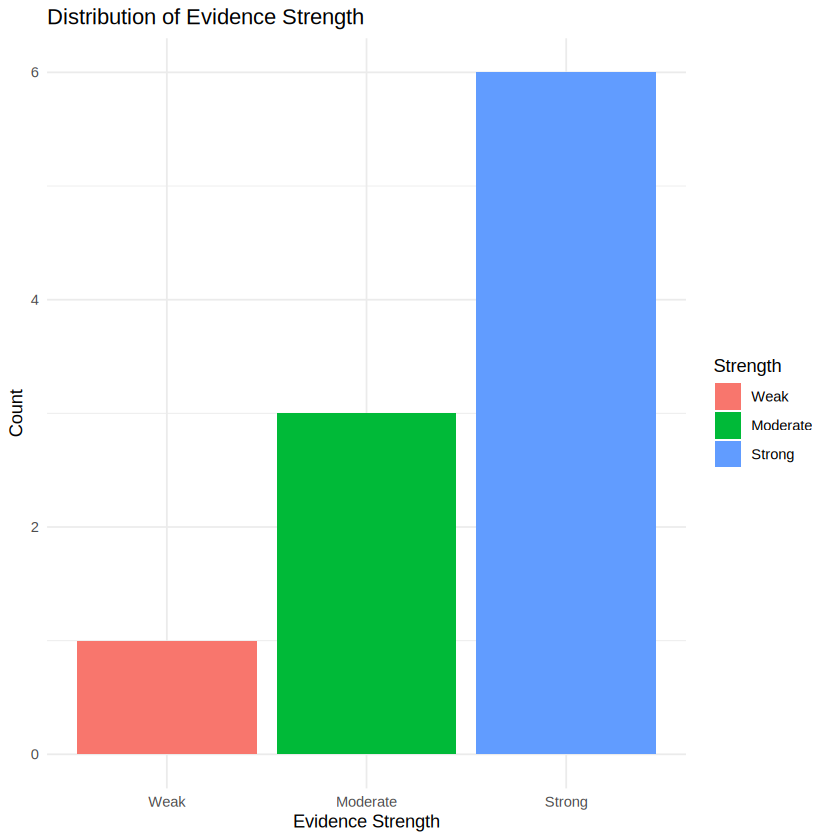

In [21]:
library(ggplot2)

df_evidence$Strength <- factor(df_evidence$Strength, levels = c("Weak", "Moderate", "Strong"))

ggplot(df_evidence, aes(x = Strength, fill = Strength)) +
  geom_bar() +
  labs(title = "Distribution of Evidence Strength",
       x = "Evidence Strength",
       y = "Count") +
  theme_minimal()


10. Final Debate Report

In [24]:
library(dplyr)

knowledge_base$Evidence_Score <- sapply(
   knowledge_base$Strength,
   get_score
)

knowledge_base$Support_Level <- sapply(
  knowledge_base$Evidence_Score,
  classify_support
)

final_report <- knowledge_base %>%
  select(
    `Argument ID`,
    Position,
    Topic,
    Claim,
    `Evidence ID`,
    `Evidence Type`,
    Strength,
    Evidence_Score,
    Support_Level
  ) %>%
  arrange(Topic, Position, `Argument ID`)

cat("\nFinal AI in Education Debate Report \n\n")
cat("Summary of Arguments and Supporting Evidence:\n\n")

for (i in 1:nrow(final_report)) {
  row <- final_report[i, ]
  cat(sprintf("Argument ID: %s (%s) - Topic: %s\n", row$`Argument ID`, row$Position, row$Topic))
  cat(sprintf("  Claim: %s\n", row$Claim))
  cat(sprintf("  Evidence: %s (Type: %s, Strength: %s, Score: %s, Support: %s)\n\n",
              row$`Evidence ID`, row$`Evidence Type`, row$Strength, row$Evidence_Score, row$Support_Level))
}

cat(" End of Report \n")


Final AI in Education Debate Report 

Summary of Arguments and Supporting Evidence:

Argument ID: A003 (For) - Topic: AI Literacy
  Claim: Allowing AI use can help students develop AI literacy.
  Evidence: E003 (Type: Policy, Strength: Strong, Score: 3, Support: Strongly Supported)

Argument ID: A004 (Against) - Topic: Academic Integrity
  Claim: Undisclosed AI-generated work may create academic integrity concerns.
  Evidence: E004 (Type: Policy, Strength: Strong, Score: 3, Support: Strongly Supported)

Argument ID: A006 (Against) - Topic: Assessment
  Claim: AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence: E006 (Type: Research, Strength: Strong, Score: 3, Support: Strongly Supported)

Argument ID: A005 (Against) - Topic: Dependency
  Claim: Excessive AI use may reduce students' independent problem-solving practice.
  Evidence: E005 (Type: Research, Strength: Moderate, Score: 2, Support: Moderately Supported)

Argument ID: A0